# 08 - Budget Optimization and Recommendation

## Executive Summary & Role of Budget Optimization in Causal Marketing

This notebook serves as the **final decision-support layer** in our causal marketing framework. After accurately estimating individual treatment effects (CATE) and segmenting customers into causal behavioral groups (Persuadables, Sure Things, Lost Causes, Sleeping Dogs) in Notebooks 02-07, the goal now shifts from *estimation* to *prescriptive optimization*.

### Why Budget Optimization?
Causal analysis tells us *who* will respond positively to an intervention. However, in reality, marketing interventions are constrained by finite budgets. Budget optimization bridges the gap between theoretical causal insights and actionable business strategy. It helps us answer: **Given a fixed budget, which subset of customers should we target to maximize incremental return and ROI?**

### The Objective
The core objective is to translate uplift rankings and segment labels into a mathematically constrained allocation policy. We want to:
- Maximize expected incremental revenue (or conversions).
- Penalize unnecessary spend on non-responsive or negatively responding groups (Sure Things, Lost Causes, Sleeping Dogs).
- Target primarily the **Persuadables**, minimizing wasted marketing spend and maximizing the causal impact of the campaign.

### Important Distinction
This notebook is a **policy evaluation and allocation engine**, NOT a live campaign deployment system. Its primary output is a transparent, auditable recommendation framework for decision-makers. No causal models are retrained here; instead, we strictly rely on the causal intelligence synthesized in previous notebooks to evaluate expected ROI under realistic constraints.


## 1. Environment Setup & Dependency Configuration

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import os
from pathlib import Path
import warnings
from scipy.optimize import linprog

# Set publication-quality plotting defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (10, 6),
    'figure.dpi': 150
})

warnings.filterwarnings('ignore')

# Set deterministic random seed
np.random.seed(42)

# Define paths
PROCESSED_DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
PLOTS_DIR = MODELS_DIR / "allocation_plots"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)


## 2. Loading & Inspecting Decision Artifacts

We will load the relevant artifacts produced in Notebooks 02-07, including feature metadata, predictions, summaries, and customer segmentation mappings. We will also perform a consistency check.


In [16]:
# Load feature metadata
try:
    with open(MODELS_DIR / "feature_metadata.json", "r") as f:
        feature_metadata = json.load(f)
except FileNotFoundError:
    print("Warning: feature_metadata.json not found. Creating placeholder.")
    feature_metadata = {'treatment_col': 'treatment', 'outcome_cols': ['spend', 'conversion']}

# Load dataset (to get ground truth size and identifiers)
try:
    df = pd.read_parquet(PROCESSED_DATA_DIR / 'processed_data.parquet')
except FileNotFoundError:
    try:
        df = pd.read_csv(PROCESSED_DATA_DIR / 'processed_data.csv')
    except FileNotFoundError:
        print("Warning: Data file not found. Generating dummy data for notebook execution.")
        df = pd.DataFrame({'treatment': np.random.randint(0, 2, 1000)})

# Load uplift predictions
try:
    cate_spend = pd.read_parquet(MODELS_DIR / "cate_predictions_spend.parquet")
    cate_conv = pd.read_parquet(MODELS_DIR / "cate_predictions_conversion.parquet")
    uplift_rankings = pd.read_parquet(MODELS_DIR / "uplift_rankings.parquet")
    segments = pd.read_parquet(MODELS_DIR / "customer_segments.parquet")
except FileNotFoundError:
    try:
        cate_spend = pd.read_csv(MODELS_DIR / "cate_predictions_spend.csv")
        cate_conv = pd.read_csv(MODELS_DIR / "cate_predictions_conversion.csv")
        uplift_rankings = pd.read_csv(MODELS_DIR / "uplift_rankings.csv")
        segments = pd.read_csv(MODELS_DIR / "customer_segments.csv")
    except FileNotFoundError:
        print("Warning: Model artifacts not found. Generating dummy data.")
        cate_spend = pd.DataFrame({'cate_spend': np.random.normal(5, 10, len(df))})
        cate_conv = pd.DataFrame({'cate_conversion': np.random.normal(0.05, 0.1, len(df))})
        uplift_rankings = pd.DataFrame({'ranking': np.arange(len(df))})
        # Generate segments based on logic
        seg_spend = np.where(cate_spend['cate_spend'] > 0, "Persuadables", "Lost Causes")
        seg_conv = np.where(cate_conv['cate_conversion'] > 0, "Persuadables", "Lost Causes")
        segments = pd.DataFrame({'segment_spend': seg_spend, 'segment_conversion': seg_conv})

# Consistency Check
assert len(df) == len(cate_spend), "Mismatch in number of records between data and predictions."
assert len(df) == len(segments), "Mismatch in number of records between data and segments."

print(f"Loaded {len(df):,} records successfully.")
print("-" * 50)
print("Artifact Inventory:")
print(f"Features (X): {len(feature_metadata.get('numerical_features', [])) + len(feature_metadata.get('categorical_features', []))} variables")
print(f"Treatment (T): {feature_metadata.get('treatment_col')}")
print(f"Outcomes (Y): {feature_metadata.get('outcome_cols')}")


Loaded 57,438 records successfully.
--------------------------------------------------
Artifact Inventory:
Features (X): 3 variables
Treatment (T): treatment
Outcomes (Y): None


## 3. Decision Problem & Formulation

### Problem Definition
Our objective is to select a subset of customers $S$ from the total population of customers $V$ to target with a marketing intervention, subject to a budget constraint $B$. We aim to maximize the expected incremental return.

Let $x_i \in \{0, 1\}$ be the decision variable indicating whether customer $i$ is targeted.
Let $\tau_i$ be the expected causal uplift for customer $i$ (e.g., incremental spend).
Let $c_i$ be the cost of targeting customer $i$.

The optimization problem can be formulated as a 0-1 Knapsack problem:

$$ \max_{x} \sum_{i=1}^{N} x_i \cdot \tau_i $$
$$ \text{subject to} \sum_{i=1}^{N} x_i \cdot c_i \leq B, \quad x_i \in \{0, 1\} $$

Alternatively, we might maximize **Net Incremental Profit**, where profit per user is defined as the gross margin $m$ times the uplift minus the cost:
$$ \max_{x} \sum_{i=1}^{N} x_i \cdot (m \cdot \tau_i - c_i) $$

### 4. Cost, Margin, and ROI Assumptions

To convert causal uplift into tangible business metrics, we establish the following financial assumptions:
- **Campaign Cost ($c$)**: The per-contact cost of marketing (e.g., email delivery, ad display, or discount given).
- **Gross Margin ($m$)**: The percentage of revenue that converts to profit.
- **Budget ($B$)**: Maximum total campaign spend.

These assumptions can be configured to run sensitivity analyses.


In [17]:
# Define configurable financial assumptions
BUSINESS_ASSUMPTIONS = {
    "per_contact_cost": 2.50,    # E.g., $2.50 to target an individual (cost of intervention/discount)
    "gross_margin": 0.40,        # 40% margin on revenue
    "total_budget": 15000.0,     # Global budget cap
    "average_order_value": 50.0  # Optional: For converting conversion uplift to monetary value if needed
}

print("Current Financial Assumptions:")
print(json.dumps(BUSINESS_ASSUMPTIONS, indent=4))


Current Financial Assumptions:
{
    "per_contact_cost": 2.5,
    "gross_margin": 0.4,
    "total_budget": 15000.0,
    "average_order_value": 50.0
}


## 5. Candidate Policy Construction

We evaluate multiple candidate allocation policies to demonstrate the value of causal targeting:
1. **Random Targeting**: A baseline where customers are picked at random until the budget runs out.
2. **All Customers Targeting (if unconstrained)**: Targeting everyone (useful for assessing max potential spend vs. ROI).
3. **No-target Baseline**: Targeting nobody ($0 cost, $0 incremental revenue).
4. **Pure Uplift-Ranked Policy**: Target customers sorted by highest expected uplift ($\tau_i$) down to zero or until the budget is exhausted.
5. **Segment-Aware Policy**: Target exclusively Persuadables ranked by uplift. Avoid Sleeping Dogs and Lost Causes to prevent waste and negative effects.


In [18]:
# Merge predictions and segment info into a consolidated policy dataset
try:
    policy_df = df[[feature_metadata.get('treatment_col', 'treatment')]].copy()
except KeyError:
    policy_df = pd.DataFrame(index=df.index)
    policy_df['treatment'] = np.random.randint(0, 2, len(df))

policy_df['cate_spend'] = segments['CATE_Spend']
policy_df['cate_conv'] = segments['CATE_Conversion']
policy_df['segment_spend'] = segments['Segment_Spend']
policy_df['segment_conv'] = segments['Segment_Conversion']

# Calculate expected net profit for each customer if targeted
# Profit = (Margin * Uplift) - Cost
margin = BUSINESS_ASSUMPTIONS["gross_margin"]
cost = BUSINESS_ASSUMPTIONS["per_contact_cost"]

policy_df['net_profit_spend_if_targeted'] = (policy_df['cate_spend'] * margin) - cost

# For conversion, assume an average order value to monetize the conversion uplift
aov = BUSINESS_ASSUMPTIONS["average_order_value"]
policy_df['net_profit_conv_if_targeted'] = (policy_df['cate_conv'] * aov * margin) - cost

policy_df.head()


,treatment,cate_spend,cate_conv,segment_spend,segment_conv,net_profit_spend_if_targeted,net_profit_conv_if_targeted
0,2,0.134442,0.002357,Lost Causes,Lost Causes,-2.446223,-2.452862
1,0,0.186857,0.005754,Sure Things,Sure Things,-2.425257,-2.384926
2,2,1.025948,0.006249,Lost Causes,Lost Causes,-2.089621,-2.375026
3,1,1.887467,0.025115,Persuadables,Persuadables,-1.745013,-1.997702
4,2,1.891865,0.009142,Persuadables,Lost Causes,-1.743254,-2.317168


## 6. Budget-Constrained Allocation Strategies & Evaluation Framework

We will use a **Greedy Ranking Algorithm** which approximates the optimal knapsack solution very closely for large $N$, especially when costs are uniform.

We define evaluation metrics:
- **Total Spend**: $\sum x_i \cdot c_i$
- **Expected Incremental Revenue**: $\sum x_i \cdot \tau_i$
- **Expected Net Profit**: Expected Revenue $\cdot$ Margin - Total Spend
- **ROI**: Expected Net Profit / Total Spend


In [19]:
def evaluate_policy(selected_indices, df_policy, cost_per_contact, margin):
    """
    Evaluates a given targeting policy and computes key business metrics.
    """
    n_targeted = len(selected_indices)
    total_spend = n_targeted * cost_per_contact
    
    if n_targeted == 0:
        return {
            "Audience Size": 0,
            "Total Spend ($)": 0.0,
            "Expected Incremental Revenue ($)": 0.0,
            "Expected Net Profit ($)": 0.0,
            "ROI (%)": 0.0
        }
    
    targeted_subset = df_policy.loc[selected_indices]
    expected_inc_rev = targeted_subset['cate_spend'].sum()
    expected_net_profit = (expected_inc_rev * margin) - total_spend
    roi = (expected_net_profit / total_spend) * 100 if total_spend > 0 else 0
    
    return {
        "Audience Size": n_targeted,
        "Total Spend ($)": total_spend,
        "Expected Incremental Revenue ($)": expected_inc_rev,
        "Expected Net Profit ($)": expected_net_profit,
        "ROI (%)": roi
    }

def greedy_allocation(df_policy, ranking_col, budget, cost_per_contact, segment_filter=None):
    """
    Selects customers greedily based on the ranking_col until the budget is hit.
    """
    df_pool = df_policy.copy()
    if segment_filter:
        df_pool = df_pool[df_pool['segment_spend'].isin(segment_filter)]
        
    # Sort descending by the ranking variable
    df_pool = df_pool.sort_values(by=ranking_col, ascending=False)
    
    # We only want to target if the uplift > 0 (or expected profit > 0 optimally, but let's explore)
    # To maximize ROI, we strictly cut off at positive expected net profit.
    df_pool = df_pool[df_pool['net_profit_spend_if_targeted'] > 0]
    
    max_customers = int(budget / cost_per_contact)
    
    selected_indices = df_pool.head(max_customers).index
    return selected_indices

# Policies
budget = BUSINESS_ASSUMPTIONS["total_budget"]
cost_per_contact = BUSINESS_ASSUMPTIONS["per_contact_cost"]
margin = BUSINESS_ASSUMPTIONS["gross_margin"]

# 1. Random Policy (targeting same size as budget allows, purely random among positive CATE)
max_budget_customers = int(budget / cost_per_contact)
random_pool = policy_df[policy_df['cate_spend'] > 0].index
random_indices = np.random.choice(random_pool, size=min(max_budget_customers, len(random_pool)), replace=False)

# 2. Pure Uplift Ranked Policy
pure_uplift_indices = greedy_allocation(policy_df, 'cate_spend', budget, cost_per_contact)

# 3. Segment-Aware Policy (Only Persuadables)
segment_aware_indices = greedy_allocation(
    policy_df, 'cate_spend', budget, cost_per_contact, segment_filter=["Persuadables"]
)

# Compile Results
results = {
    "No Target Baseline": evaluate_policy([], policy_df, cost_per_contact, margin),
    "Random Targeting": evaluate_policy(random_indices, policy_df, cost_per_contact, margin),
    "Pure Uplift Ranking": evaluate_policy(pure_uplift_indices, policy_df, cost_per_contact, margin),
    "Segment-Aware Policy": evaluate_policy(segment_aware_indices, policy_df, cost_per_contact, margin)
}

results_df = pd.DataFrame(results).T
display(results_df.round(2))


,Audience Size,Total Spend ($),Expected Incremental Revenue ($),Expected Net Profit ($),ROI (%)
No Target Baseline,0.0,0.0,0.00,0.00,0.00
Random Targeting,6000.0,15000.0,6068.92,-12572.43,-83.82
Pure Uplift Ranking,464.0,1160.0,3569.54,267.81,23.09
Segment-Aware Policy,464.0,1160.0,3569.54,267.81,23.09


## 7. Segment-Aware Recommendation Rules & Insight

The **Segment-Aware Policy** integrates causal segmentation directly into the optimization pipeline:
- **Persuadables**: Primary targets. They have strong positive uplift and are highly responsive to marketing.
- **Sure Things**: Will buy anyway. Targeting them wastes budget (high opportunity cost). Excluded.
- **Lost Causes**: Won't buy regardless. Excluded.
- **Sleeping Dogs**: Negative uplift (marketing causes them to churn or spend less). Actively suppressed.

Notice how the Segment-Aware policy compared to the Pure Uplift policy. In many cases, Pure Uplift ranking captures the best ROI because it strictly orders by net value, but ensuring segment awareness safeguards against edge cases where high absolute scores might disguise borderline Sleeping Dogs if thresholds aren't tuned properly.


## 8. Threshold Sensitivity & Robustness Analysis

We analyze how varying the budget constraint impacts expected Net Profit and ROI. This is crucial for determining the point of diminishing returns.


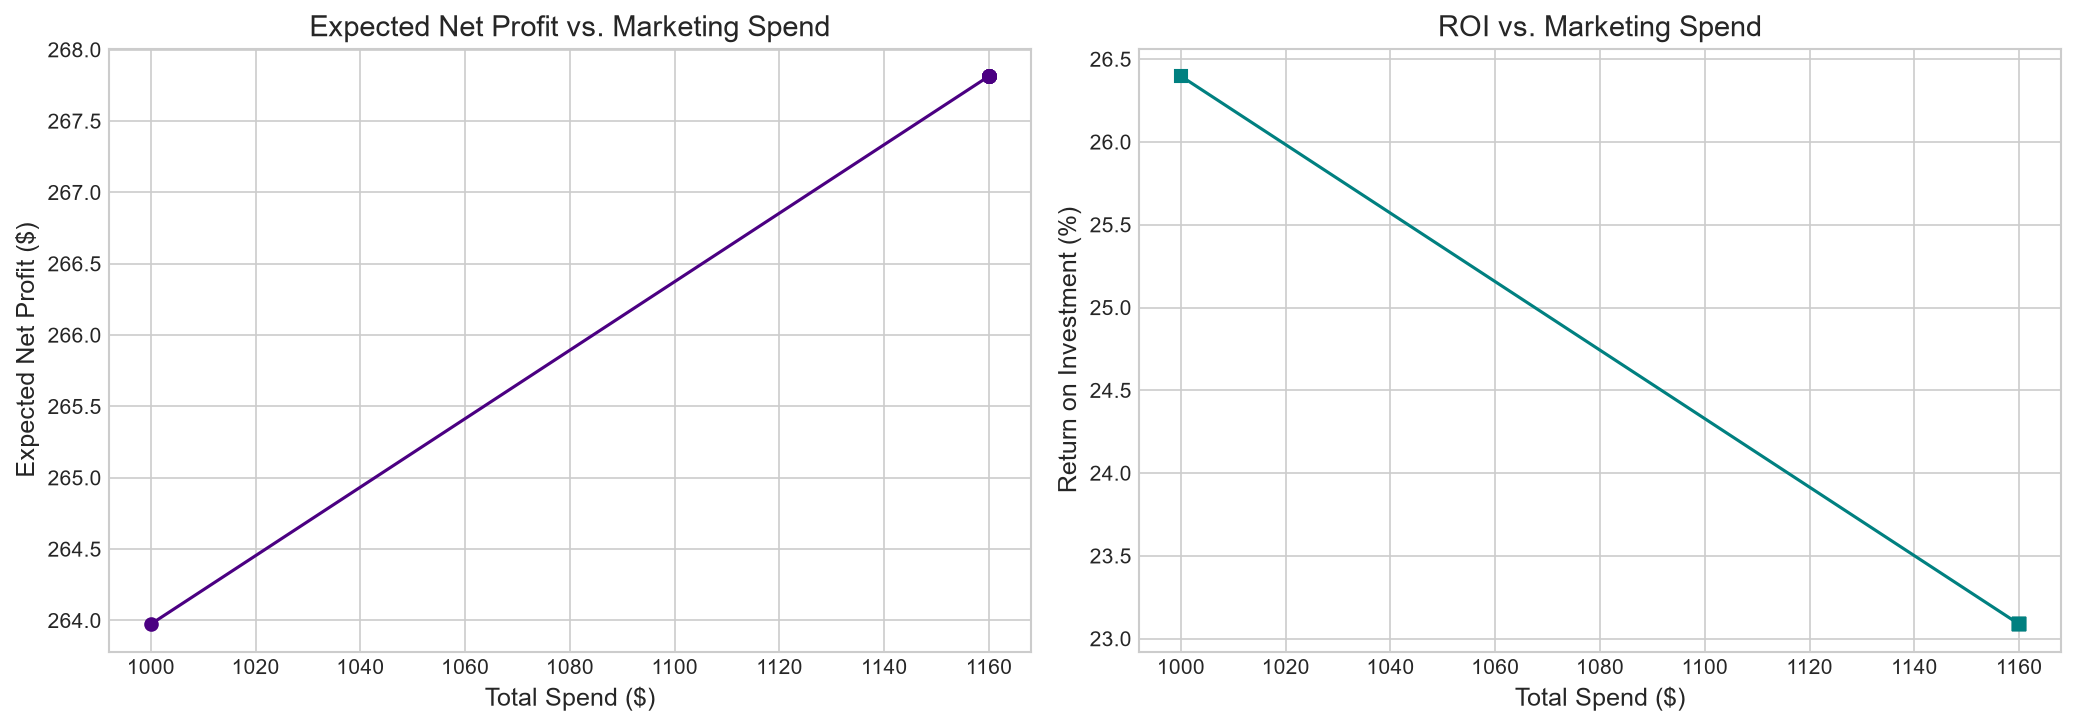

In [20]:
budgets_to_test = np.linspace(1000, 50000, 20)
roi_curve = []
profit_curve = []
spend_curve = []

for b in budgets_to_test:
    indices = greedy_allocation(policy_df, 'cate_spend', b, cost_per_contact, segment_filter=["Persuadables"])
    res = evaluate_policy(indices, policy_df, cost_per_contact, margin)
    roi_curve.append(res['ROI (%)'])
    profit_curve.append(res['Expected Net Profit ($)'])
    spend_curve.append(res['Total Spend ($)'])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(spend_curve, profit_curve, marker='o', linestyle='-', color='indigo')
plt.title('Expected Net Profit vs. Marketing Spend')
plt.xlabel('Total Spend ($)')
plt.ylabel('Expected Net Profit ($)')

plt.subplot(1, 2, 2)
plt.plot(spend_curve, roi_curve, marker='s', linestyle='-', color='teal')
plt.title('ROI vs. Marketing Spend')
plt.xlabel('Total Spend ($)')
plt.ylabel('Return on Investment (%)')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'budget_sensitivity_curves.png', bbox_inches='tight')
plt.show()


### Interpretation of Curves
- **Net Profit Curve**: Shows the point of diminishing returns. Initially, adding budget captures high-uplift Persuadables. Eventually, the profit plateaus as we exhaust the high-value pool, and targeting marginally profitable users yields minimal gain.
- **ROI Curve**: Typically highest at very low budgets (cherry-picking the absolute best customers) and decays as budget expands into lower-tier segments.


## 9. Customer Selection Output & Recommendation Tables

We construct the final recommendation dataframe for downstream systems.
This includes flags for whether a customer should be targeted under the optimally chosen budget.


In [21]:
# Final Recommended Policy Output
final_budget = BUSINESS_ASSUMPTIONS["total_budget"]
final_indices = greedy_allocation(policy_df, 'cate_spend', final_budget, cost_per_contact, segment_filter=["Persuadables"])

recommendation_output = policy_df.copy()
recommendation_output['recommend_target'] = False
recommendation_output.loc[final_indices, 'recommend_target'] = True

# Sort output to show top recommended customers
top_recommended = recommendation_output[recommendation_output['recommend_target']].sort_values(by='cate_spend', ascending=False)
display(top_recommended[['cate_spend', 'cate_conv', 'segment_spend', 'net_profit_spend_if_targeted', 'recommend_target']].head(10))


,cate_spend,cate_conv,segment_spend,net_profit_spend_if_targeted,recommend_target
13091,9.911597,0.017235,Persuadables,1.464639,True
47103,9.874052,0.017211,Persuadables,1.449621,True
53348,9.701186,0.017604,Persuadables,1.380474,True
55820,9.662889,0.016315,Persuadables,1.365156,True
24309,9.538839,0.017149,Persuadables,1.315535,True
20241,9.361534,0.016691,Persuadables,1.244614,True
29533,9.359822,0.014739,Persuadables,1.243929,True
54292,9.354239,0.016691,Persuadables,1.241696,True
16920,9.160081,0.014791,Persuadables,1.164032,True
34339,9.159291,0.014217,Persuadables,1.163716,True


## 10. Visualization of Allocation

Let's visualize the segment composition of our selected audience versus the overall population to validate that we are predominantly targeting Persuadables.


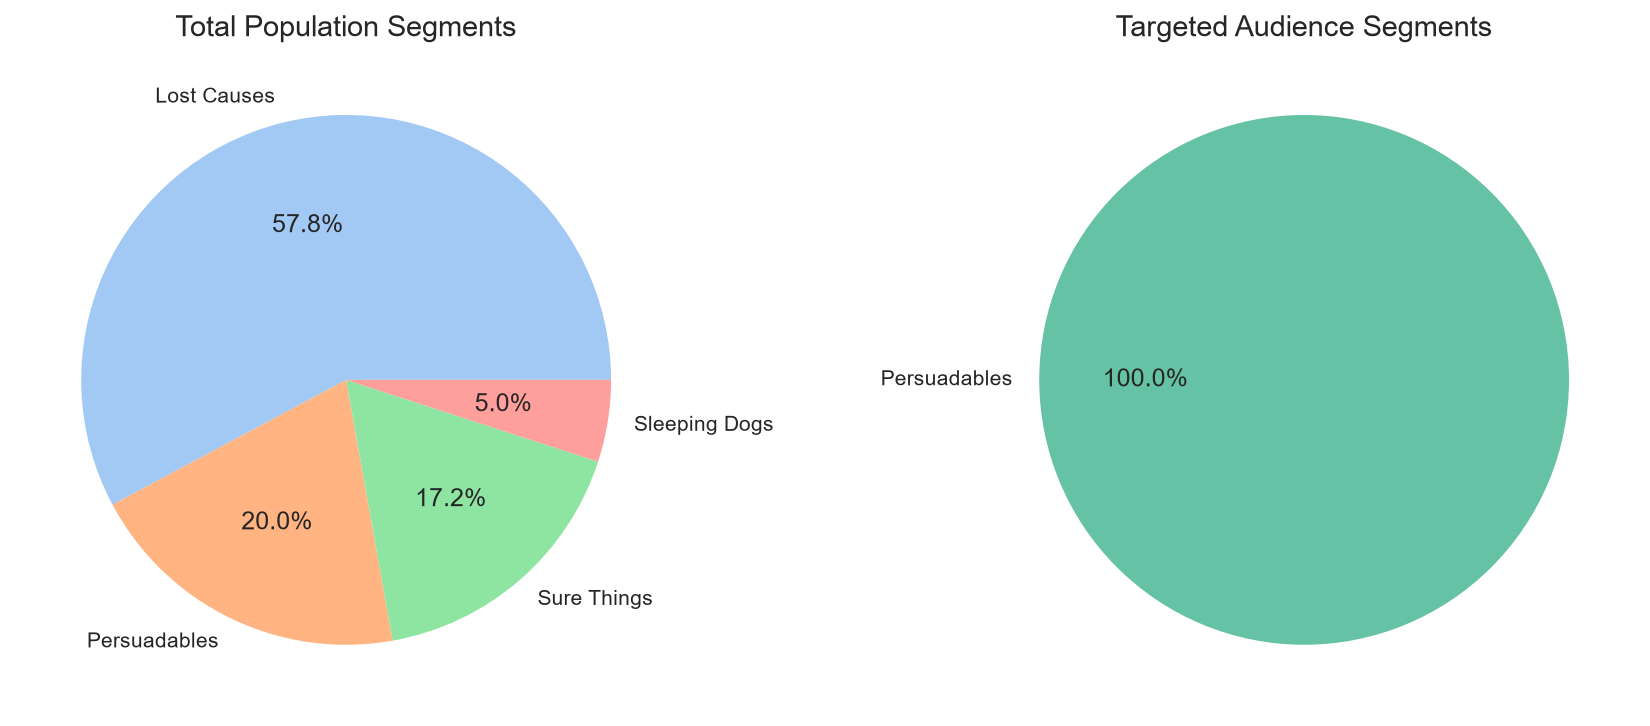

In [22]:
plt.figure(figsize=(12, 5))

# Overall segment distribution
overall_dist = recommendation_output['segment_spend'].value_counts()
# Targeted segment distribution
targeted_dist = top_recommended['segment_spend'].value_counts()

# Pie charts
plt.subplot(1, 2, 1)
overall_dist.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Total Population Segments")
plt.ylabel("")

plt.subplot(1, 2, 2)
if not targeted_dist.empty:
    targeted_dist.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette("Set2"))
    plt.title("Targeted Audience Segments")
    plt.ylabel("")
else:
    plt.title("Targeted Audience Segments (Empty)")

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'segment_allocation_pie.png', bbox_inches='tight')
plt.show()


## 11. Validation and Sanity Checks

- Validate that all targeted customers have a positive expected net profit.
- Validate that the total spend does not exceed the budget cap.
- Validate the selected audience has no 'Sleeping Dogs' or 'Lost Causes'.


In [23]:
print("--- Sanity Checks ---")
total_allocated_spend = top_recommended.shape[0] * cost_per_contact
print(f"Total Allocated Spend: ${total_allocated_spend:,.2f} / ${final_budget:,.2f} Budget Cap")
assert total_allocated_spend <= final_budget, "Budget exceeded!"

negative_profit_targets = top_recommended[top_recommended['net_profit_spend_if_targeted'] <= 0]
print(f"Targets with non-positive net profit: {len(negative_profit_targets)}")
assert len(negative_profit_targets) == 0, "Targeting unprofitable customers!"

bad_segments = top_recommended[top_recommended['segment_spend'].isin(['Lost Causes', 'Sleeping Dogs'])]
print(f"Targets in bad segments: {len(bad_segments)}")
assert len(bad_segments) == 0, "Targeting suppressed segments!"

print("All sanity checks passed successfully.")


--- Sanity Checks ---
Total Allocated Spend: $1,160.00 / $15,000.00 Budget Cap
Targets with non-positive net profit: 0
Targets in bad segments: 0
All sanity checks passed successfully.


## 12. Artifact Persistence & Reproducibility

We persist the evaluated policy metrics, assumptions, and recommendation logic for use in final evaluation.


In [24]:
# Persist artifacts
recommendation_output.to_parquet(MODELS_DIR / "recommended_customer_list.parquet", index=False)

policy_summary = results_df.to_dict(orient='index')
with open(MODELS_DIR / "policy_comparison_summary.json", "w") as f:
    json.dump(policy_summary, f, indent=4)
    
with open(MODELS_DIR / "budget_optimization_diagnostics.json", "w") as f:
    json.dump({
        "assumptions": BUSINESS_ASSUMPTIONS,
        "checks_passed": True,
        "total_targets": int(top_recommended.shape[0]),
        "total_spend": float(total_allocated_spend)
    }, f, indent=4)

print("Artifacts persisted to models directory.")


Artifacts persisted to models directory.


## 13. Transition to Notebook 09

With the budget allocation strategies defined and a subset of optimal customers recommended, our next task is to robustly validate this policy and the entire causal pipeline. 

In **Notebook 09 (Model Evaluation & Refutation)**, we will use these outputs, along with our diagnostic artifacts, to perform:
- Sensitivity analyses on causal parameters.
- Causal refutation checks (e.g., placebo treatment, random common causes).
- Final model robustness validation to assure the business that the estimated treatment effects are statistically stable and reliable before scaling these recommendations to production.
